In [12]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load the uploaded JSON file
file_path = 'OOB_base_sensitivity.json'
with open(file_path, 'r') as file:
    data = json.load(file)

# Select the 'unvac_children' section and aggregate each sublevel into one summation per number
unvac_children_data = data['unvac_children']

# Aggregating the unvac_children data by scenario number (second key)
aggregated_by_scenario = {}

# Iterating over all antigens and summing values by scenario
for antigen, scenarios in unvac_children_data.items():
    for scenario, value in scenarios.items():
        if scenario not in aggregated_by_scenario:
            aggregated_by_scenario[scenario] = 0
        aggregated_by_scenario[scenario] += value

# Converting the aggregated data into a DataFrame for better visualization
aggregated_by_scenario_df = pd.DataFrame(aggregated_by_scenario.items(), columns=['Scenario', 'Total_Unvaccinated'])
aggregated_by_scenario_df = aggregated_by_scenario_df.sort_values(by='Scenario').reset_index(drop=True)
# aggregated_by_scenario_df



In [13]:
with open('base_sensitivity.json', 'r') as file:
    second_dataset = json.load(file)

# Extract 'unvac_children' from the second dataset and aggregate by scenario
second_unvac_children = second_dataset['unvac_children']
aggregated_second_dataset = {}

for antigen, scenarios in second_unvac_children.items():
    for scenario, value in scenarios.items():
        if scenario not in aggregated_second_dataset:
            aggregated_second_dataset[scenario] = 0
        aggregated_second_dataset[scenario] += value

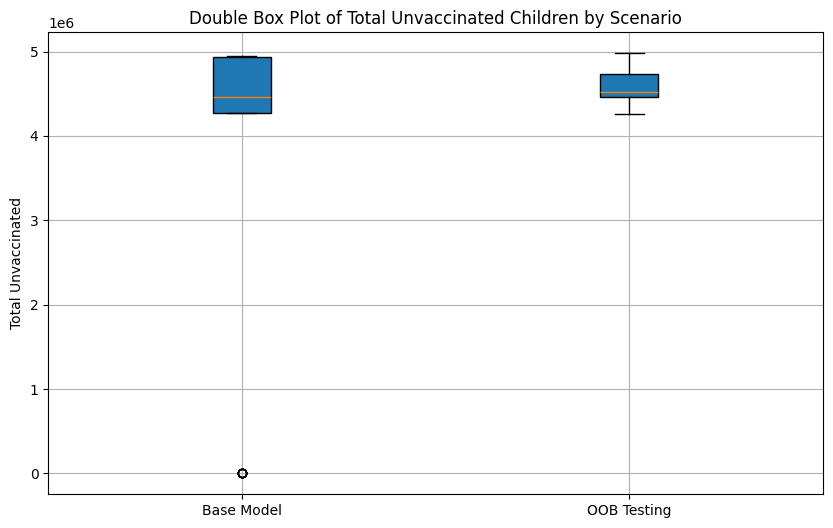

In [16]:


# Combine both datasets into a DataFrame for plotting
combined_data = pd.DataFrame({
    'Scenario': aggregated_by_scenario_df['Scenario'],
    'Dataset 2': aggregated_by_scenario_df['Total_Unvaccinated'],
    'Dataset 1': aggregated_second_dataset.values()
})

# Create a double box plot for the two datasets
plt.figure(figsize=(10, 6))
plt.boxplot([combined_data['Dataset 1'], combined_data['Dataset 2']], labels=['Base Model', 'OOB Testing'], patch_artist=True)
plt.title('Double Box Plot of Total Unvaccinated Children by Scenario')
plt.ylabel('Total Unvaccinated')
plt.grid(True)
plt.show()


In [17]:
aggregated_second_dataset

{'5': 4268951.164770308,
 '35': 4930904.651420209,
 '16': 4268951.164770308,
 '20': 4466661.412932072,
 '12': 4952327.312978477,
 '30': 4268951.164770307,
 '24': 4466661.412932071,
 '28': 4952327.312978477,
 '8': 4952327.312978477,
 '17': 4930904.651420208,
 '1': 454.4044247929487,
 '23': 4268951.164770308,
 '32': 454.4044247928774,
 '22': 4952327.312978476,
 '6': 454.4044247929531,
 '19': 4952327.312978477,
 '11': 454.4044247928774,
 '31': 4952327.312978477,
 '9': 4930904.651420208,
 '14': 4268951.164770308,
 '3': 4466661.412932071,
 '29': 4930904.651420209,
 '7': 4466661.412932071,
 '33': 4268951.164770308,
 '25': 4930904.651420208,
 '34': 4466661.412932072,
 '4': 4930904.651420207,
 '13': 4466661.412932072,
 '15': 4930904.651420209,
 '2': 4952327.312978477,
 '27': 454.404424792924,
 '10': 4268951.164770308,
 '26': 4466661.412932072,
 '18': 454.4044247929589,
 '21': 454.4044247929589}